In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as pgo
from plotly import express as px
import ipynbname
import uproot
from pathlib import Path
import pandas as pd

In [2]:
base_dir = ipynbname.path().parents[3]
sim_data_dir = Path("/data/fanghan/opengate_sim/data/")
dc_spect_mc_root_filename = "run_0_detector_hits.root"
# Show branches of the DetectorActor tree
with uproot.open(sim_data_dir / dc_spect_mc_root_filename) as file:
    file["DetectorHitsActor"].show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
RunID                | int32_t                  | AsDtype('>i4')
ThreadID             | int32_t                  | AsDtype('>i4')
EventID              | int32_t                  | AsDtype('>i4')
TrackID              | int32_t                  | AsDtype('>i4')
PreKineticEnergy     | double                   | AsDtype('>f8')
PrePosition_X        | double                   | AsDtype('>f8')
PrePosition_Y        | double                   | AsDtype('>f8')
PrePosition_Z        | double                   | AsDtype('>f8')
PrePositionLocal_X   | double                   | AsDtype('>f8')
PrePositionLocal_Y   | double                   | AsDtype('>f8')
PrePositionLocal_Z   | double                   | AsDtype('>f8')
PostKineticEnergy    | double                   | AsDtype('>f8')
PostPosition_X       | double                   | AsDtype(

In [3]:
# Scan through all runs in the folder
# We need to parse the run number from the filename, so we can sort them correctly
# First get a list of all root files in the directory
root_files = list(sim_data_dir.glob("run_*_detector_hits.root"))
# Extract run numbers and sort files by run number
def extract_run_number(filename):
    # Assuming filename format is "run_{run_number}_detector_hits.root"
    parts = filename.stem.split("_")
    for i, part in enumerate(parts):
        if part == "run" and i + 1 < len(parts):
            return int(parts[i + 1])
    return -1  # Return -1 if run number not found
# Sort files by extracted run number
root_files.sort(key=extract_run_number)
print("Sorted root files by run number:")
for f in root_files:
    print(f.name)

for root_file in root_files:
    with uproot.open(root_file) as file:
        # Print unique RunId values in the file
        run_ids = file["DetectorHitsActor"]["RunID"].array(library="np")
        unique_run_ids = np.unique(run_ids)
        print(f"File: {root_file.name}, Unique RunIds: {unique_run_ids}")


Sorted root files by run number:
run_0_detector_hits.root
run_1_detector_hits.root
run_2_detector_hits.root
run_3_detector_hits.root
run_4_detector_hits.root
run_5_detector_hits.root
run_6_detector_hits.root
run_7_detector_hits.root
run_8_detector_hits.root
run_9_detector_hits.root
File: run_0_detector_hits.root, Unique RunIds: [0]
File: run_1_detector_hits.root, Unique RunIds: [0]
File: run_2_detector_hits.root, Unique RunIds: [0]
File: run_3_detector_hits.root, Unique RunIds: [0]
File: run_4_detector_hits.root, Unique RunIds: [0]
File: run_5_detector_hits.root, Unique RunIds: [0]
File: run_6_detector_hits.root, Unique RunIds: [0]
File: run_7_detector_hits.root, Unique RunIds: [0]
File: run_8_detector_hits.root, Unique RunIds: [0]
File: run_9_detector_hits.root, Unique RunIds: [0]


In [4]:
# Load all runs into one Polars DataFrame (fast path)
import polars as pl

tree_paths = [f"{root_file}:DetectorHitsActor" for root_file in root_files]
if not tree_paths:
    raise FileNotFoundError(f"No ROOT files found in {sim_data_dir}")

# Read all files in one pass to avoid slow repeated DataFrame concatenation
hits_arrays = uproot.concatenate(tree_paths, library="np")
hits_pl = pl.DataFrame(hits_arrays)

# Keep pandas copy so downstream cells using pandas APIs still work
hits_df = hits_pl.to_pandas()

# Precompute values used by later cells
unique_event_ids, event_counts = np.unique(
    hits_df["EventID"].to_numpy(), return_counts=True
)
event_pos_xyz = hits_df[["EventPosition_X", "EventPosition_Y", "EventPosition_Z"]].to_numpy()

print(f"Loaded {len(hits_df):,} detector hits from {len(tree_paths)} run files.")
print(hits_pl.head())

Loaded 446,248 detector hits from 10 run files.
shape: (5, 29)
┌───────┬──────────┬─────────┬─────────┬───┬─────────────┬─────────────┬─────────────┬─────────────┐
│ RunID ┆ ThreadID ┆ EventID ┆ TrackID ┆ … ┆ EventKineti ┆ ParticleTyp ┆ TrackCreato ┆ ProcessDefi │
│ ---   ┆ ---      ┆ ---     ┆ ---     ┆   ┆ cEnergy     ┆ e           ┆ rProcess    ┆ nedStep     │
│ i32   ┆ i32      ┆ i32     ┆ i32     ┆   ┆ ---         ┆ ---         ┆ ---         ┆ ---         │
│       ┆          ┆         ┆         ┆   ┆ f64         ┆ str         ┆ str         ┆ str         │
╞═══════╪══════════╪═════════╪═════════╪═══╪═════════════╪═════════════╪═════════════╪═════════════╡
│ 0     ┆ 30       ┆ 181451  ┆ 1       ┆ … ┆ 0.14        ┆ gamma       ┆ none        ┆ phot        │
│ 0     ┆ 30       ┆ 183911  ┆ 1       ┆ … ┆ 0.14        ┆ gamma       ┆ none        ┆ phot        │
│ 0     ┆ 30       ┆ 184941  ┆ 1       ┆ … ┆ 0.14        ┆ gamma       ┆ none        ┆ phot        │
│ 0     ┆ 30       ┆ 185548 

## Calculate Sensitivity (Detector Efficiency)

In [6]:
# Calculate Sensitivity using only RunID = 0
run_0_hits = hits_pl.filter(pl.col("RunID") == 0)
unique_event_ids, event_counts = np.unique(
    run_0_hits["EventID"].to_numpy(), return_counts=True
)
total_events = 64_000_000
detected_events = len(unique_event_ids)
detection_efficiency = detected_events / total_events
print(f"Total simulated events: {total_events}")
print(f"Detected events: {detected_events}")
print(f"Detection efficiency: {detection_efficiency:.3%}")

Total simulated events: 64000000
Detected events: 397071
Detection efficiency: 0.620%


In [5]:
# Print total number of unique events and detection efficiency
per_run_events = 64_000_000
n_runs = len(root_files)
total_events = per_run_events * n_runs
# Get unique EventIDs with unique RunID combinations
unique_event_run_combinations = hits_df[["RunID", "EventID"]].drop_duplicates()
detected_events = len(unique_event_run_combinations)
detection_efficiency = detected_events / total_events
print(f"Total simulated events: {total_events:,}")
print(f"Detected events: {detected_events:,}")
print(f"Detection efficiency: {detection_efficiency:.3%}")


Total simulated events: 640,000,000
Detected events: 397,071
Detection efficiency: 0.062%


In [5]:
# Histogram the counts of unique EventIDs
hist, bin_edges = np.histogram(event_counts, bins=np.arange(0.5, event_counts.max() + 1.5, 1))

fig = px.bar(
    x=bin_edges[:-1]+0.5,  # Center the bins
    y=hist,
    labels={'x': 'Number of hits per Event', 'y': 'Number of Events'},
    title="Distribution of hits per Event"

)

# 2. Replicate the 'edgecolor' and 'width' look
fig.update_traces(
    marker_line_color='black', 
    marker_line_width=1.5,
    opacity=0.8
)

fig.update_layout(bargap=0)

fig.show()

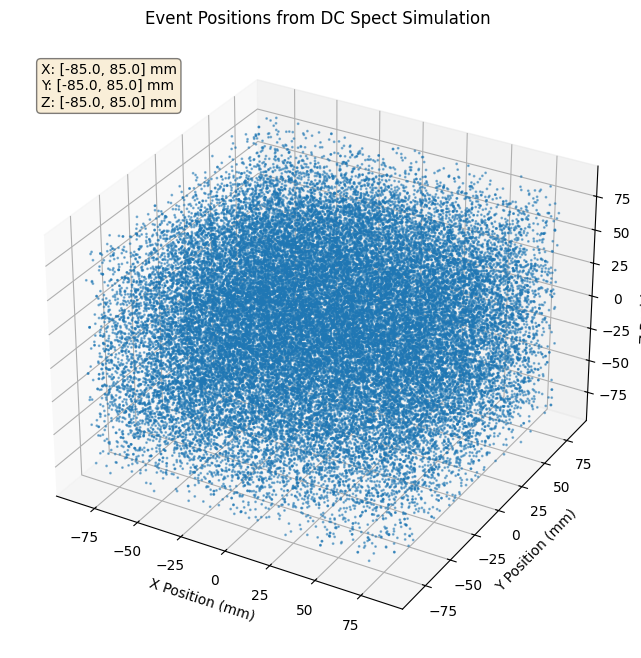

In [6]:
# Plot event positions in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(event_pos_xyz[:, 0], event_pos_xyz[:, 1], event_pos_xyz[:, 2], s=1, alpha=0.5)
ax.set_xlabel('X Position (mm)')
ax.set_ylabel('Y Position (mm)')
ax.set_zlabel('Z Position (mm)')
# Add a text box showing the max and min of each coordinate
textstr = '\n'.join((
    f'X: [{event_pos_xyz[:, 0].min():.1f}, {event_pos_xyz[:, 0].max():.1f}] mm',
    f'Y: [{event_pos_xyz[:, 1].min():.1f}, {event_pos_xyz[:, 1].max():.1f}] mm',
    f'Z: [{event_pos_xyz[:, 2].min():.1f}, {event_pos_xyz[:, 2].max():.1f}] mm',
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text2D(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
ax.set_title('Event Positions from DC Spect Simulation')
plt.show()

In [8]:
total_events = 64_000_000
detected_events = len(unique_event_ids)
detection_efficiency = detected_events / total_events
print(f"Total simulated events: {total_events}")
print(f"Detected events: {detected_events}")
print(f"Detection efficiency: {detection_efficiency:.3%}")

Total simulated events: 64000000
Detected events: 39945
Detection efficiency: 0.062%
